# ENTRENANDO MODELO DE ML PARA CLASIFICAR INGRESANTES A UNIVERSIDAD
## DATASET: https://www.datosabiertos.gob.pe/dataset/postulantes-al-concurso-de-admisi%C3%B3n-de-la-universidad-nacional-de-ingenier%C3%ADa-uni

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [ ]:
df = pd.read_csv('/content/uni_cleaned.csv')
df

,COLEGIO_DEPA,ESPECIALIDAD,SEXO,INGRESO,egreso_postulacion,edad
0,ÁNCASH,INGENIERÍA DE TELECOMUNICACIONES,FEMENINO,NO,4,20
1,LIMA,INGENIERÍA MECÁNICA,MASCULINO,NO,5,21
2,LIMA,ARQUITECTURA,FEMENINO,NO,1,17
3,LIMA,INGENIERÍA CIVIL,MASCULINO,NO,2,19
4,LIMA,INGENIERÍA AMBIENTAL,FEMENINO,NO,6,22
...,...,...,...,...,...,...
15281,LIMA,INGENIERÍA CIVIL,MASCULINO,NO,4,21
15282,CALLAO,INGENIERÍA CIVIL,FEMENINO,NO,2,19
15283,AYACUCHO,ARQUITECTURA,FEMENINO,NO,1,17
15284,LIMA,ARQUITECTURA,FEMENINO,NO,2,19


In [ ]:
df.dtypes

,0
COLEGIO_DEPA,object
ESPECIALIDAD,object
SEXO,object
INGRESO,object
egreso_postulacion,int64
edad,int64


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

## 4.1 IDENTIFICAMOS VARIABLES CATEGORICAS

In [ ]:
categorical_columns = df.select_dtypes(object).columns
categorical_columns

Index(['COLEGIO_DEPA', 'ESPECIALIDAD', 'SEXO', 'INGRESO'], dtype='object')

## 4.2 CREAMOS LISTA POR TIPO DE CODIFICACIÓN

In [ ]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
COLEGIO_DEPA
LIMA             11843
CALLAO             690
JUNÍN              239
ICA                229
ÁNCASH             209
AYACUCHO           202
JUNIN              196
ANCASH             163
PUNO               156
CAJAMARCA          153
LAMBAYEQUE         145
HUANCAVELICA        97
CUSCO               91
APURÍMAC            87
PASCO               84
AMAZONAS            81
HUÁNUCO             80
AREQUIPA            75
HUANUCO             67
LA LIBERTAD         67
APURIMAC            58
SAN MARTÍN          42
SAN MARTIN          39
PIURA               38
UCAYALI             38
TACNA               38
MADRE DE DIOS       24
LORETO              22
MOQUEGUA            16
TUMBES              11
ARGENTINA            2
VENEZUELA            1
CHILE                1
ECUADOR              1
ITALIA               1
Name: count, dtype: int64
**************************************************
ESPECIALIDAD
INGENIERÍA CIVIL                         

In [ ]:
paises_a_excluir = ['ARGENTINA', 'VENEZUELA', 'CHILE', 'ECUADOR', 'ITALIA']
df = df[~df['COLEGIO_DEPA'].isin(paises_a_excluir)].copy()
df['COLEGIO_DEPA'].value_counts()

,count
COLEGIO_DEPA,
LIMA,11843
CALLAO,690
JUNÍN,239
ICA,229
ÁNCASH,209
AYACUCHO,202
JUNIN,196
ANCASH,163
PUNO,156


In [ ]:
df['COLEGIO_DEPA'] = df['COLEGIO_DEPA'].apply(lambda x: 'LIMA' if x == 'LIMA' else 'PROVINCIA')
df['COLEGIO_DEPA'].value_counts()

,count
COLEGIO_DEPA,
LIMA,11843
PROVINCIA,3437


In [ ]:
top_especialidades = [
    'INGENIERÍA CIVIL',
    'INGENIERÍA DE SISTEMAS',
    'ARQUITECTURA',
    'INGENIERÍA MECATRÓNICA',
    'INGENIERÍA INDUSTRIAL'
]

df['ESPECIALIDAD'] = df['ESPECIALIDAD'].apply(lambda x: x if x in top_especialidades else 'OTRAS INGENIERIAS')
df['ESPECIALIDAD'].value_counts()

,count
ESPECIALIDAD,
OTRAS INGENIERIAS,5905
INGENIERÍA CIVIL,2745
INGENIERÍA DE SISTEMAS,2368
ARQUITECTURA,1643
INGENIERÍA MECATRÓNICA,1351
INGENIERÍA INDUSTRIAL,1268


In [ ]:
df = df[df['ESPECIALIDAD'] != 'OTRAS INGENIERIAS'].copy()
df['ESPECIALIDAD'].value_counts()

,count
ESPECIALIDAD,
INGENIERÍA CIVIL,2745
INGENIERÍA DE SISTEMAS,2368
ARQUITECTURA,1643
INGENIERÍA MECATRÓNICA,1351
INGENIERÍA INDUSTRIAL,1268


In [ ]:
ordinal_cols = ['SEXO','INGRESO']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['SEXO', 'INGRESO'] ['COLEGIO_DEPA', 'ESPECIALIDAD']


## 4.4 CODIFICAMOS USANDO LOS MODULSO COMPOSE Y PREPROCESSING DE SKLEARN

In [ ]:
import sklearn.compose
import sklearn.preprocessing

### 4.4.1 CREAMOS UN TRANSFORMER

In [ ]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['SEXO', 'INGRESO']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['COLEGIO_DEPA', 'ESPECIALIDAD'])])

### 4.4.2 APLICAMOS EL TRANSFOMER A EL DATASET

In [ ]:
import numpy as np

transformed_data = transformer.fit_transform(df)

# If the transformer outputs a sparse matrix (e.g., from OneHotEncoder), convert it to a dense array.
if hasattr(transformed_data, 'toarray'):
    transformed_data = transformed_data.toarray()

# Check if the transformed data is a 2D array with 1 column, where each element is an array (row)
# This specific condition addresses the ValueError: Shape of passed values is (N, 1), indices imply (N, M).
if transformed_data.ndim == 2 and transformed_data.shape[1] == 1 and transformed_data.dtype == object and isinstance(transformed_data[0,0], (np.ndarray, list)):
    # Stack the inner arrays from the single column to form the correct 2D array
    transformed_data = np.vstack(transformed_data[:, 0])

data_transformed_df = (
    pd.DataFrame(
        transformed_data,
        columns = transformer.get_feature_names_out(),
        index=df.index
    )
)
data_transformed_df

,ordinalencoder__SEXO,ordinalencoder__INGRESO,onehotencoder__COLEGIO_DEPA_LIMA,onehotencoder__COLEGIO_DEPA_PROVINCIA,onehotencoder__ESPECIALIDAD_ARQUITECTURA,onehotencoder__ESPECIALIDAD_INGENIERÍA CIVIL,onehotencoder__ESPECIALIDAD_INGENIERÍA DE SISTEMAS,onehotencoder__ESPECIALIDAD_INGENIERÍA INDUSTRIAL,onehotencoder__ESPECIALIDAD_INGENIERÍA MECATRÓNICA,remainder__egreso_postulacion,remainder__edad
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,19.0
6,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,18.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,21.0
10,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...
15281,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,21.0
15282,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,19.0
15283,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
15284,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,19.0


In [ ]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,SEXO,INGRESO,COLEGIO_DEPA_LIMA,COLEGIO_DEPA_PROVINCIA,ESPECIALIDAD_ARQUITECTURA,ESPECIALIDAD_INGENIERÍA CIVIL,ESPECIALIDAD_INGENIERÍA DE SISTEMAS,ESPECIALIDAD_INGENIERÍA INDUSTRIAL,ESPECIALIDAD_INGENIERÍA MECATRÓNICA,egreso_postulacion,edad
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,19.0
6,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,18.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,21.0
10,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...
15281,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,21.0
15282,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,19.0
15283,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
15284,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,19.0


In [ ]:
data_transformed_df.dtypes

,0
SEXO,float64
INGRESO,float64
COLEGIO_DEPA_LIMA,float64
COLEGIO_DEPA_PROVINCIA,float64
ESPECIALIDAD_ARQUITECTURA,float64
ESPECIALIDAD_INGENIERÍA CIVIL,float64
ESPECIALIDAD_INGENIERÍA DE SISTEMAS,float64
ESPECIALIDAD_INGENIERÍA INDUSTRIAL,float64
ESPECIALIDAD_INGENIERÍA MECATRÓNICA,float64
egreso_postulacion,float64


In [ ]:
data_transformed_df.to_csv('uni_transformed.csv',index=None)

In [ ]:
df = pd.read_csv('/content/uni_transformed.csv')
df

,SEXO,INGRESO,COLEGIO_DEPA_LIMA,COLEGIO_DEPA_PROVINCIA,ESPECIALIDAD_ARQUITECTURA,ESPECIALIDAD_INGENIERÍA CIVIL,ESPECIALIDAD_INGENIERÍA DE SISTEMAS,ESPECIALIDAD_INGENIERÍA INDUSTRIAL,ESPECIALIDAD_INGENIERÍA MECATRÓNICA,egreso_postulacion,edad
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,19.0
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,18.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,21.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...
9370,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,21.0
9371,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,19.0
9372,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,17.0
9373,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,19.0


In [ ]:
df['INGRESO'].value_counts()

,count
INGRESO,
0.0,8602
1.0,773


In [ ]:
variable_dep = 'INGRESO'

In [ ]:
corr_matrix = df.corr()
corr_dep = corr_matrix[[variable_dep]].sort_values(by=variable_dep,ascending=False)
corr_dep

,INGRESO
INGRESO,1.000000
egreso_postulacion,0.077361
SEXO,0.071852
edad,0.065363
ESPECIALIDAD_INGENIERÍA MECATRÓNICA,0.060297
ESPECIALIDAD_INGENIERÍA INDUSTRIAL,0.026590
COLEGIO_DEPA_LIMA,0.020086
ESPECIALIDAD_INGENIERÍA DE SISTEMAS,0.002455
COLEGIO_DEPA_PROVINCIA,-0.020086
ESPECIALIDAD_INGENIERÍA CIVIL,-0.024147


In [ ]:
cols = corr_dep.index.tolist()
cols.remove(variable_dep)
cols

['egreso_postulacion',
 'SEXO',
 'edad',
 'ESPECIALIDAD_INGENIERÍA MECATRÓNICA',
 'ESPECIALIDAD_INGENIERÍA INDUSTRIAL',
 'COLEGIO_DEPA_LIMA',
 'ESPECIALIDAD_INGENIERÍA DE SISTEMAS',
 'COLEGIO_DEPA_PROVINCIA',
 'ESPECIALIDAD_INGENIERÍA CIVIL',
 'ESPECIALIDAD_ARQUITECTURA']

In [ ]:
X = df[cols].values
y = df[variable_dep].values.reshape(-1,1)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Conteo de clases después de SMOTE:")
print(pd.Series(y_train).value_counts())

Conteo de clases después de SMOTE:
0.0    6869
1.0    6869
Name: count, dtype: int64


# CREAMOS UN CODIGO PARA PODER EVALUAR VARIOS MODELOS

## 1 - IMPORTAMOS LIBRERIAS

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

## 2 - DEFINIMOS LOS MODELOS A EVALUAR

In [ ]:
modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf')
}

## 3 - CREAMOS FUNCIÓN DE EVALUACIÓN

In [ ]:
def evaluar_clasificador(modelo, nombre):
    modelo.fit(X_train, y_train.ravel())
    y_pred = modelo.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n{nombre}:')
    print(f'Accuracy: {accuracy:.4f}')
    #print(classification_report(y_test, y_pred))
    return accuracy

## 4 - ENTRENAMOS Y COMPARAMOS MODELOS

In [ ]:
resultados_clasificacion = {}
for nombre, modelo in modelos_clasificacion.items():
    resultados_clasificacion[nombre] = evaluar_clasificador(modelo, nombre)

# Mostrar el mejor modelo
mejor_modelo_clasificacion = max(resultados_clasificacion, key=resultados_clasificacion.get)
print(f'\nEl mejor modelo es: {mejor_modelo_clasificacion} con un Accuracy de {resultados_clasificacion[mejor_modelo_clasificacion]:.4f}')


Regresión Logística:
Accuracy: 0.6197

Random Forest:
Accuracy: 0.7280

k-Nearest Neighbors:
Accuracy: 0.9051

Gradient Boosting:
Accuracy: 0.7173

SVM (RBF):
Accuracy: 0.6395

El mejor modelo es: k-Nearest Neighbors con un Accuracy de 0.9051


## 5. GRAFICAMOS RESULTADOS

/tmp/ipykernel_2538/219317408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')


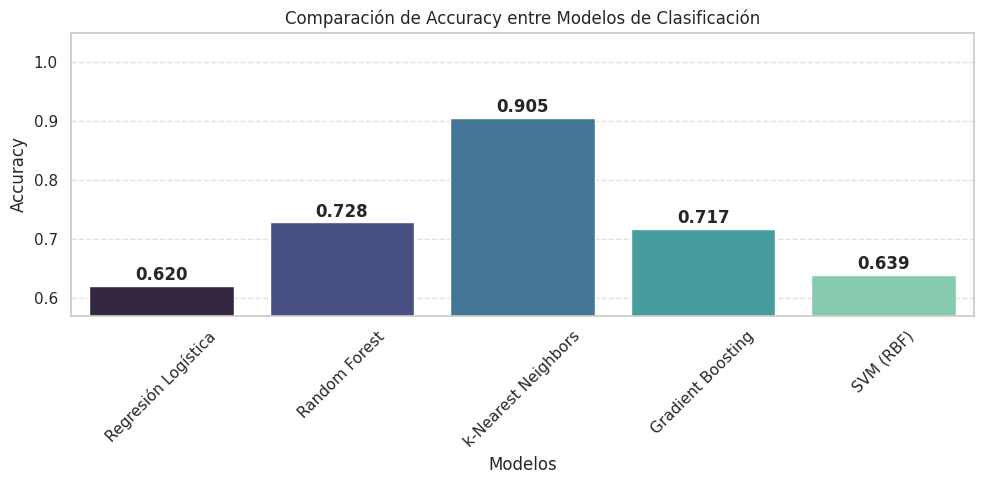

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparación del Accuracy entre modelos de clasificación
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(resultados_clasificacion.keys()), y=list(resultados_clasificacion.values()), palette='mako')

# Agregar etiquetas en cada barra
for index, value in enumerate(resultados_clasificacion.values()):
    ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.ylim(min(resultados_clasificacion.values()) - 0.05, 1.05)
plt.xlabel('Modelos')
plt.ylabel('Accuracy')
plt.title('Comparación de Accuracy entre Modelos de Clasificación')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## CREAMOS UNA MATRIZ DE CONFUSIÓN

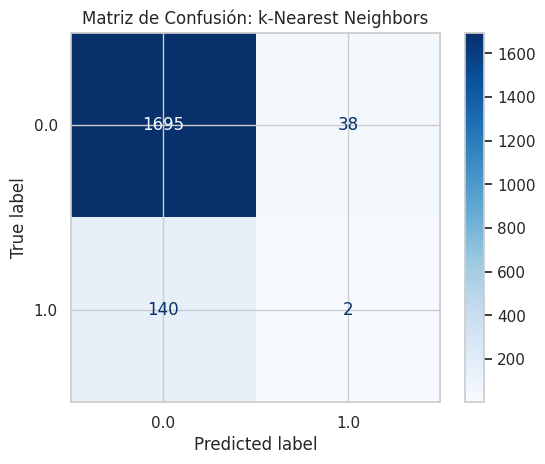

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluación del mejor modelo de clasificación
modelo_clasificacion_seleccionado = modelos_clasificacion[mejor_modelo_clasificacion]
y_pred_clasificacion = modelo_clasificacion_seleccionado.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_clasificacion)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_clasificacion_seleccionado.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión: {mejor_modelo_clasificacion}')
plt.show()

In [ ]:
# Crea un DataFrame con un nuevo conjunto de datos de ejemplo
# Asegúrate de que las columnas estén en el mismo orden que 'cols' y que coincidan con la estructura después del preprocesamiento

# Ejemplo de un nuevo postulante:
# egreso_postulacion: 2 (segunda postulación)
# SEXO: 1.0 (Masculino)
# edad: 19
# Especialidad: INGENIERÍA CIVIL
# COLEGIO_DEPA: LIMA

new_data_point = pd.DataFrame([
    {
        'egreso_postulacion': 2.0,
        'SEXO': 1.0,
        'edad': 19.0,
        'ESPECIALIDAD_INGENIERÍA MECATRÓNICA': 0.0,
        'ESPECIALIDAD_INGENIERÍA INDUSTRIAL': 0.0,
        'COLEGIO_DEPA_LIMA': 1.0,
        'ESPECIALIDAD_INGENIERÍA DE SISTEMAS': 0.0,
        'COLEGIO_DEPA_PROVINCIA': 0.0,
        'ESPECIALIDAD_INGENIERÍA CIVIL': 1.0,
        'ESPECIALIDAD_ARQUITECTURA': 0.0
    }
], columns=cols)

# Escalar los nuevos datos utilizando el mismo scaler que se usó para entrenar
new_data_scaled = scaler.transform(new_data_point.values)

# Obtener el mejor modelo de clasificación
modelo_clasificacion_seleccionado = modelos_clasificacion[mejor_modelo_clasificacion]

# Realizar la predicción con los nuevos datos escalados
prediction = modelo_clasificacion_seleccionado.predict(new_data_scaled)

# Imprimir la predicción
print(f"Predicción para el nuevo postulante (0=NO INGRESO, 1=SI INGRESO): {prediction[0]}")

if prediction[0] == 1:
    print("El modelo predice que el postulante SI INGRESARÁ.")
else:
    print("El modelo predice que el postulante NO INGRESARÁ.")

Predicción para el nuevo postulante (0=NO INGRESO, 1=SI INGRESO): 0.0
El modelo predice que el postulante NO INGRESARÁ.
